# CSDE: Corrected Spatial Differential Expression

**CSDE** (`scviva.tl.csde`, `scviva.tl.CSDEAnalysis`) corrects for systematic errors introduced by automated spatial transcriptomics pipelines (cell mis-segmentation, mislabeling) before they propagate into false discoveries. It combines a large automated-annotation set with a small manually-validated subset via prediction-powered inference (PPI) to recover unbiased differential-expression estimates -- log-fold-changes, p-values, and BH-adjusted q-values -- with valid confidence intervals, for exactly two spatial populations of one cell type at a time (e.g. "inside tumour" vs. "outside tumour" macrophages).

**Real data, real upstream model.** This tutorial reuses the exact Xenium mouse-brain dataset from the {doc}`resolVI tutorial </tutorials/resolVI_tutorial>` and trains a real semisupervised `scviva.model.ResolVI` on it. `predicted_celltype` is the dataset's original automated annotation (Leiden clustering of a ProSeg-resegmented Xenium run) -- exactly the kind of error-prone automated label CSDE is designed to correct. We use ResolVI's own re-prediction as a proxy validation signal (agreement/disagreement with `predicted_celltype`) to stand in for the manually-validated ground-truth subset that upstream CSDE's annotation UI would otherwise produce -- see the caveat in section 3 and `docs/user_guide/models/csde.md`.


## 1. Load the real Xenium dataset and train ResolVI

Same `tutorial_xenium_brain.h5ad` as the resolVI tutorial: a Xenium mouse-brain section with raw counts in `.layers["counts"]`, spatial coordinates in `.obsm["X_spatial"]`, and the dataset's original automated cell-type calls in `.obs["predicted_celltype"]`.

In [ ]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import scviva

from scviva.tools.csde import CSDEAnalysis

In [1]:
sc.set_figure_params(figsize=(4, 4))
save_dir = tempfile.TemporaryDirectory()
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

rng = np.random.default_rng(0)
scviva.settings.seed = 0
print("Last run with scVIVA-Tools version:", scviva.__version__)
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scVIVA-Tools version: 0.1.6
Last run with scvi-tools version: 1.5.0.post1


In [2]:
adata_path = os.path.join(save_dir.name, "tutorial_xenium_brain.h5ad")
adata = sc.read(
    adata_path, backup_url="https://exampledata.scverse.org/scvi-tools/tutorial_xenium_brain.h5ad"
)
adata


  0%|          | 0.00/170M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 130604 × 248
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'fov', 'predicted_celltype'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'log1p'
    obsm: 'X_resolvi_transferred', 'X_spatial', 'X_umap_transferred'
    layers: 'counts', None

`predicted_celltype` is the automated label we want to correct DE estimates for. `hemisphere` is a real spatial split of the tissue (not an injected synthetic signal) -- left vs. right hemisphere, from `X_spatial`'s first coordinate -- giving us two spatial populations of the same cell type to compare, as CSDE requires.

In [3]:
adata.obs["predicted_celltype"].value_counts()


predicted_celltype
Astrocytes                            17315
Oligodendrocyte                       14567
Fibroblast                            10070
Endothelial Cells                      9775
Inhibitory Neurons Hypothalamus        9284
Excitatory Neurons Amygdala            8640
Excitatory Neurons Thalamus            7947
Excitatory Neurons L5                  7004
Excitatory Neurons L2/3                6393
Inhibitory Neurons Putamen             5753
Inhibitory Neurons Cortical            5711
Excitatory Neurons L4                  5500
Excitatory Neurons L6                  5052
Microglia                              4141
Oligodendrocyte Precursor Cells        3872
Excitatory Neurons Dentate Gyrus       3283
Excitatory Neurons Cornu ammonis       2787
Ependymal Cells                        2202
Inhibitory Neurons Pallidum             658
Excitatory Neurons Amygdala medial      650
Name: count, dtype: int64

/tmp/ipykernel_699631/3601840795.py:2: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="hemisphere", spot_size=30)


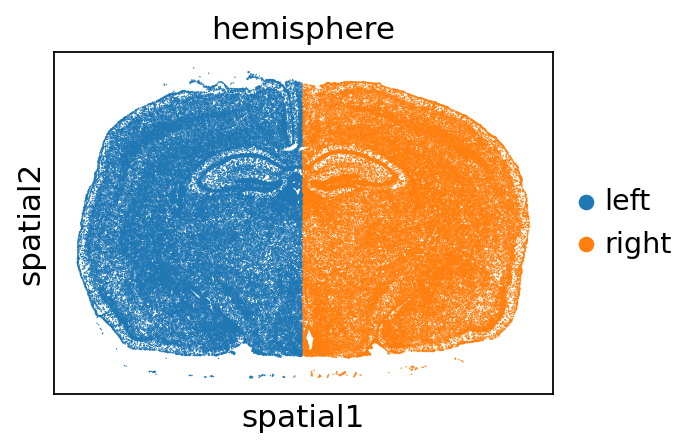

In [4]:
adata.obs["hemisphere"] = np.where(adata.obsm["X_spatial"][:, 0] > 5000, "right", "left")
sc.pl.spatial(adata, color="hemisphere", spot_size=30)


We train a real semisupervised `ResolVI` model on the full dataset, using `predicted_celltype` as the (automated, potentially noisy) label supervision -- the same model and setup used in the resolVI tutorial, just without the reference/query split (not needed for this demo).

In [5]:
from scviva.model._resolvi import ResolVI

scviva.model.ResolVI.setup_anndata(adata, labels_key="predicted_celltype", layer="counts")
resolvi_model = scviva.model.ResolVI(adata, semisupervised=True)
resolvi_model.train(max_epochs=50)


Preparing data for training. This may take a while. RAPIDS SingleCell will be used if installed.


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/rapids_singlecell/__init__.py:38: UserWarning: 
Multiple rapids_singlecell packages are installed: rapids-singlecell, rapids-singlecell-cu13
Please uninstall all versions and reinstall only one:
  pip uninstall rapids-singlecell rapids-singlecell-cu13

  _detect_duplicate_installation()


INFO     Generating sequential column names                                                                        


INFO     Generating sequential column names                                                                        


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 0 in adata.obs['_scvi_ind_x'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi/data/_utils.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  return sparse_csr_tensor(


Training:   0%|          | 0/50 [00:00<?, ?it/s]

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scviva/module/_resolvae.py:382: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  concentration=torch.tensor(
2026-08-04 16:25:10 | [INFO] Guessed max_plate_nesting = 2


`Trainer.fit` stopped: `max_epochs=50` reached.


Sampling local variables, batch:   0%|          | 0/262 [00:00<?, ?it/s]

/tmp/ipykernel_699631/337695543.py:3: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["predicted_celltype", "resolvi_predicted"], spot_size=30)
... storing 'resolvi_predicted' as categorical


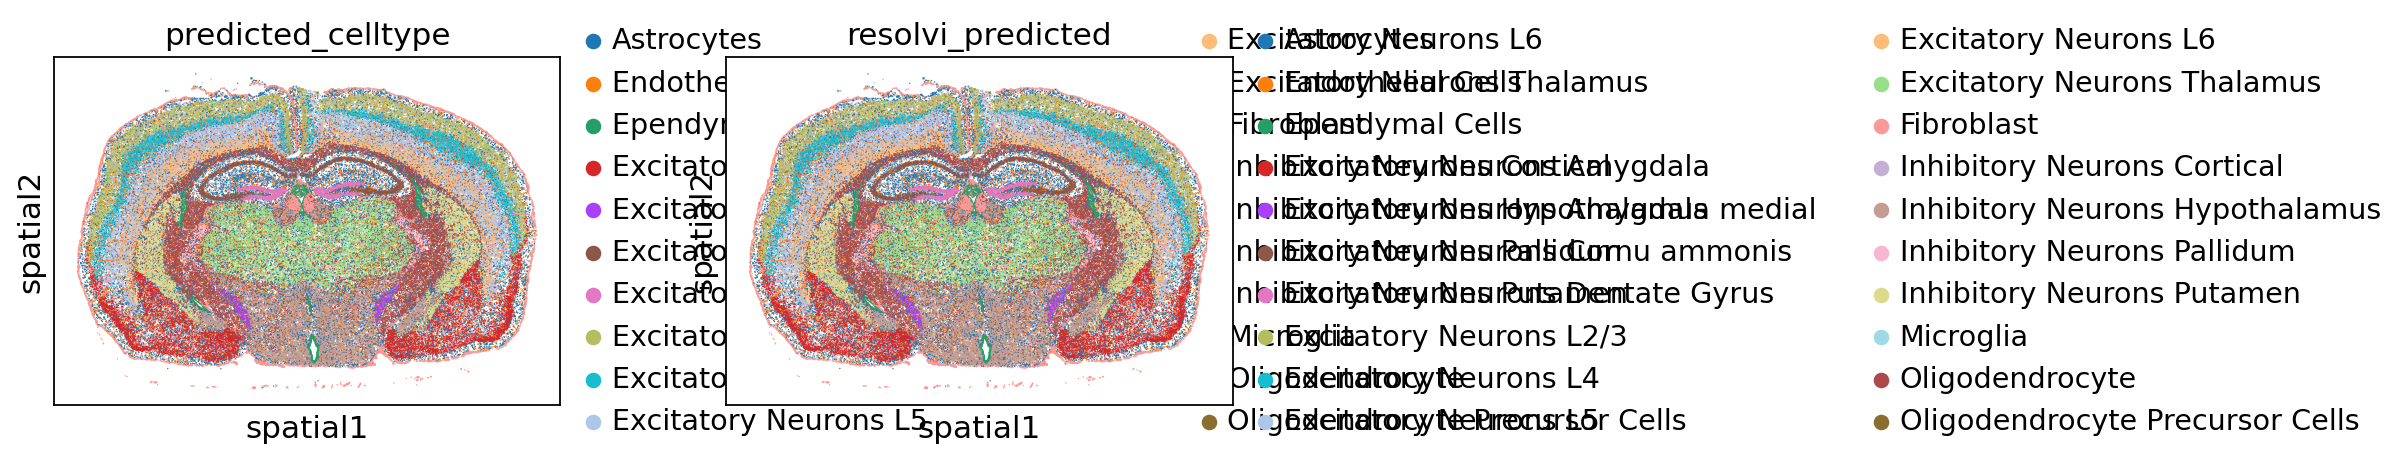

In [6]:
adata.obsm["resolvi_celltypes"] = resolvi_model.predict(adata, num_samples=3, soft=True)
adata.obs["resolvi_predicted"] = adata.obsm["resolvi_celltypes"].idxmax(axis=1)
sc.pl.spatial(adata, color=["predicted_celltype", "resolvi_predicted"], spot_size=30)


## 2. Pick a cell type present in both hemispheres

CSDE compares two spatial populations of the *same* cell type. We pick the `predicted_celltype` category with the most balanced (largest minimum) representation across both hemispheres, then build a combined `population` label so it can be passed as `pred_cell_pop_key`.

In [7]:
counts_by_hemisphere = adata.obs.groupby(["predicted_celltype", "hemisphere"]).size().unstack(fill_value=0)
target_cell_type = counts_by_hemisphere.min(axis=1).idxmax()
print("Selected cell type:", target_cell_type)
counts_by_hemisphere.loc[target_cell_type]


Selected cell type: Astrocytes


/tmp/ipykernel_699631/2545778326.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_hemisphere = adata.obs.groupby(["predicted_celltype", "hemisphere"]).size().unstack(fill_value=0)


hemisphere
left     8702
right    8613
Name: Astrocytes, dtype: int64

In [8]:
adata.obs["population"] = (
    adata.obs["predicted_celltype"].astype(str) + "_" + adata.obs["hemisphere"].astype(str)
)
cell_pop_a = f"{target_cell_type}_left"  # reference
cell_pop_b = f"{target_cell_type}_right"  # target
cell_pop_a, cell_pop_b


('Astrocytes_left', 'Astrocytes_right')

## 3. Ground-truth validated subset: a ResolVI-agreement proxy

Upstream CSDE's real ground-truth subset comes from a human manually validating a small importance-sampled set of cells (`scripts/export.py` + `scripts/annotate.py`, a Streamlit UI) -- neither is ported into scviva-tools (see `docs/user_guide/models/csde.md`, "What's not (yet) in scviva-tools"). As a stand-in here we take a random subsample and set `is_correct` to whether ResolVI's own re-prediction (`resolvi_predicted`, informed by expression *and* spatial neighborhood, and trained to be robust to mis-segmentation/background noise) agrees with the original automated label (`predicted_celltype`) -- a real model-based correction signal, not a random guess, but still **not a substitute for actual manual validation**. On real data, replace this with an actually-validated `is_correct` column from upstream CSDE's annotation workflow.

In [9]:
n_validate = 300
validate_idx = rng.choice(adata.n_obs, size=n_validate, replace=False)
adata_gt = adata[validate_idx].copy()

adata_gt.obs["is_correct"] = (
    adata_gt.obs["predicted_celltype"].astype(str) == adata_gt.obs["resolvi_predicted"].astype(str)
)
adata_gt.obs["sampling_weight"] = 1.0
adata_gt.obs["is_correct"].value_counts()


is_correct
True     290
False     10
Name: count, dtype: int64

## 4. Run CSDE

We compare the selected cell type's cells in the left hemisphere (reference) against the right hemisphere (target), using the base `CSDEAnalysis` constructor directly with plain `AnnData` objects and column names -- not `CSDEAnalysis.from_spatialdata()`, which expects a real upstream annotation directory (`config.json`, `metadata.csv`, `annotations.json`) that we don't have here. `adata_pred` is the full automated population (the whole dataset); `adata_gt` is the ResolVI-agreement-validated subset from above.

In [10]:
analysis = CSDEAnalysis(
    adata_pred=adata,
    adata_gt=adata_gt,
    pred_cell_pop_key="population",
    cell_pop_a=cell_pop_a,
    cell_pop_b=cell_pop_b,
    gt_key="is_correct",
    layer_name="counts",
)
analysis.fit(noise_model="poisson", optimizer="lbfgs")
results = analysis.test_differential_expression()
results.sort_values("p_value_adj").head(20)


Hessian computation:   0%|          | 0/3 [00:00<?, ?it/s]

Hessian computation:  33%|███▎      | 1/3 [00:00<00:00,  3.12it/s]

Hessian computation:  67%|██████▋   | 2/3 [00:00<00:00,  3.43it/s]

Hessian computation: 100%|██████████| 3/3 [00:00<00:00,  4.74it/s]

Hessian computation: 100%|██████████| 3/3 [00:00<00:00,  4.24it/s]

...

Hessian computation:  33%|███▎      | 1/3 [00:00<00:00,  3.88it/s]

Hessian computation:  67%|██████▋   | 2/3 [00:00<00:00,  3.72it/s]

Hessian computation: 100%|██████████| 3/3 [00:00<00:00,  5.20it/s]

Hessian computation: 100%|██████████| 3/3 [00:00<00:00,  4.72it/s]

,log_fold_change,p_value,p_value_adj
feature_name,,,
Sntb1,1.984894,7.675276e-08,0.000010
Trbc2,-1.540597,7.093056e-08,0.000010
Sst,-1.555178,1.763640e-07,0.000015
Th,-1.389092,6.336080e-07,0.000039
Crh,-1.405813,9.343436e-07,0.000039
Fmod,-1.403166,1.111456e-06,0.000039
Rspo2,-2.810729,1.017344e-06,0.000039
Pln,-1.384043,2.026049e-06,0.000063
Tacr1,-1.281866,4.952786e-06,0.000136


## 5. Volcano plot

A simple volcano plot of the corrected log-fold-change against the BH-adjusted p-value, consistent with how other scviva-tools tutorials visualize DE results.

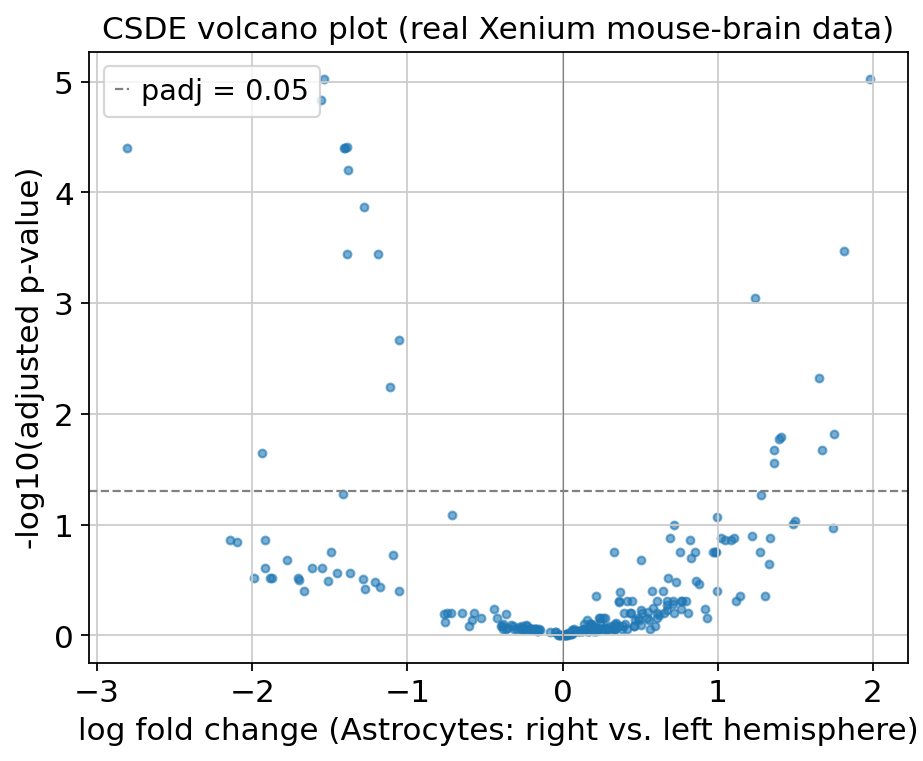

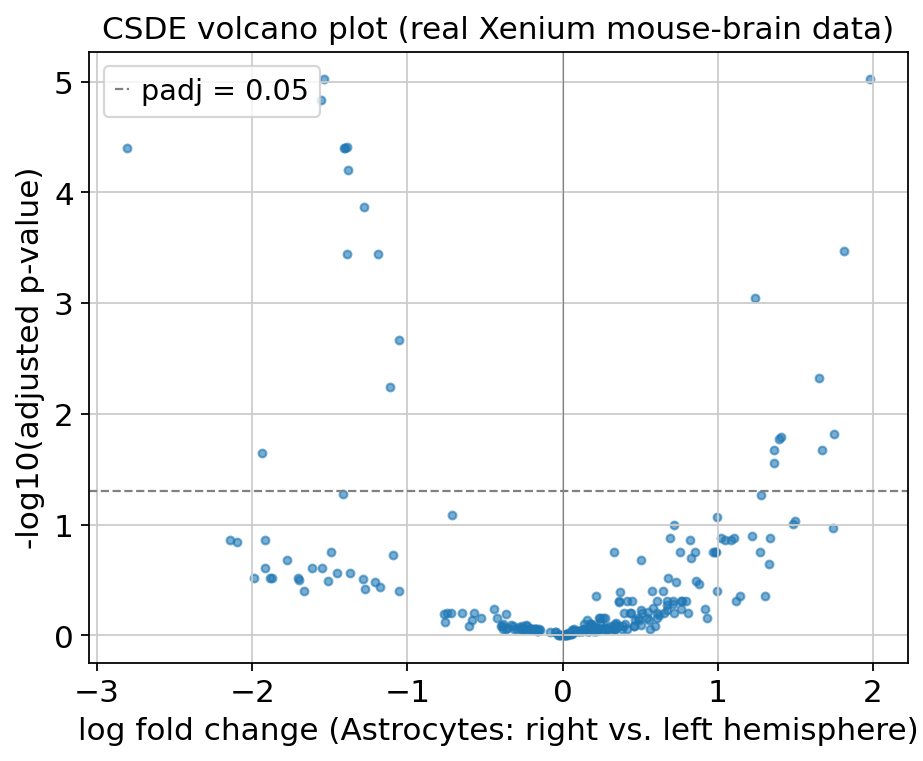

In [11]:
neglog10_padj = -np.log10(results["p_value_adj"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(results["log_fold_change"], neglog10_padj, s=12, alpha=0.6, color="tab:blue")
ax.axhline(-np.log10(0.05), color="grey", linestyle="--", linewidth=1, label="padj = 0.05")
ax.axvline(0, color="grey", linestyle="-", linewidth=0.5)
ax.set_xlabel(f"log fold change ({target_cell_type}: right vs. left hemisphere)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("CSDE volcano plot (real Xenium mouse-brain data)")
ax.legend()
fig.tight_layout()
fig


## Closing notes

This tutorial ran CSDE end-to-end on real data: the same Xenium mouse-brain dataset as the resolVI tutorial, a real trained `scviva.model.ResolVI`, a real spatial (hemisphere) population split, and real gene counts. The one piece still stood in for is the manually-validated ground-truth subset -- we used ResolVI-prediction agreement with the original automated label as a proxy, not actual human validation.

For a fully real run:

-   Replace the ResolVI-agreement proxy with an actually manually-validated `is_correct` column, produced by upstream [YosefLab/CSDE](https://github.com/YosefLab/CSDE)'s `scripts/export.py` + `scripts/annotate.py`, then load it with `CSDEAnalysis.from_spatialdata()` instead of the base constructor used here.

See `docs/user_guide/models/csde.md` for a full summary of what's ported into scviva-tools (the PPI-based differential-expression step) and what is not (the panel-export and manual-validation UI), and the upstream [YosefLab/CSDE](https://github.com/YosefLab/CSDE) repository for the complete export/annotate/DE pipeline.